<a href="https://colab.research.google.com/github/shriyam943/Haar-Cascade/blob/main/Haar_Cascade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install opencv-python
from google.colab import files


In [ ]:
uploaded = files.upload()

Saving IMG_5678.jpg to IMG_5678.jpg


In [ ]:
import cv2
import matplotlib.pyplot as plt

In [ ]:
img_path = list(uploaded.keys())[0]

In [ ]:
img = cv2.imread(img_path)

In [ ]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [ ]:
face_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )
eye_detector = cv2.CascadeClassifier(
    cv2.data.haarcascades + 'haarcascade_eye.xml'
    )



In [ ]:
faces = face_detector.detectMultiScale(
      gray,
      scaleFactor=1.1,
      minNeighbors=5,
      )

In [ ]:
for (x, y, w, h) in faces:

  cv2.rectangle(
  img,
  (x, y),
  (x + w, y + h),
  (0, 255, 0),
  8
         )

roi_gray = gray[y:y+h, x:x+w]
roi_color = img[y:y+h, x:x+w]



In [ ]:
eyes = eye_detector.detectMultiScale(
     roi_gray[0:int(h/2), :]
)


In [ ]:
for (ex, ey, ew, eh) in eyes:

    cv2.rectangle(
        roi_color,
        (ex, ey),
        (ex + ew, ey + eh),
        (255, 0, 0),
        6
    )

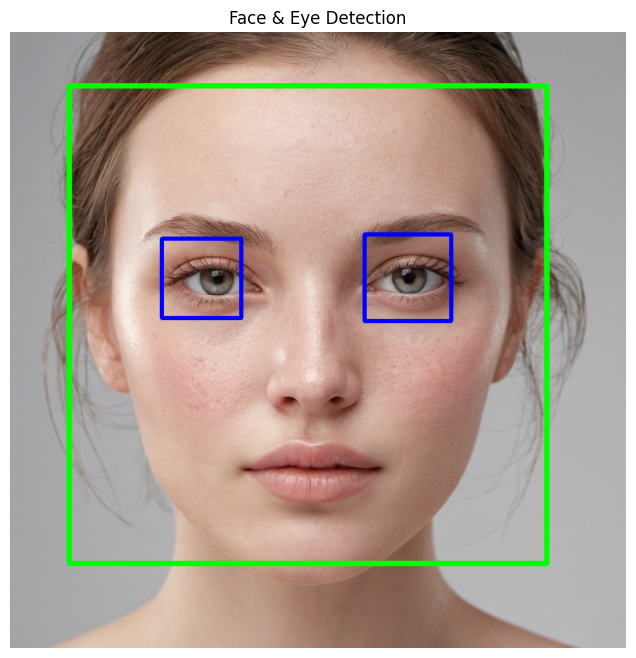

In [ ]:
plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Face & Eye Detection")
plt.axis("off")
plt.show()